# Regresión Polinomial aplicada al proyecto NeuroTrack
### Notebook de implementación del algoritmo

**Materia:** Extracción de Conocimiento en Bases de Datos​  
**Tema del equipo:** Regresión Polinomial
**Proyecto relacionado:** NeuroTrack — sistema de monitoreo de síntomas de Parkinson


**Profesor:** María Reina Zarate Nava

---

Este notebook desarrolla el flujo completo de un modelo de **Regresión Polinomial**, aplicado a un caso relacionado con NeuroTrack:

1. Carga de librerías
2. Carga del dataset
3. Preprocesamiento
4. Entrenamiento del algoritmo
5. Evaluación del modelo

> **Nota:** el dataset utilizado en este notebook es **simulado**, con fines ilustrativos y académicos para esta entrega. Representa el tipo de análisis que NeuroTrack busca habilitar a futuro a partir de los registros de síntomas capturados en la aplicación.

## Contexto del caso

NeuroTrack busca apoyar el seguimiento de síntomas motores en personas con Parkinson. Uno de los patrones clínicos conocidos es el efecto del medicamento (levodopa) sobre la severidad del temblor a lo largo del tiempo: al tomar la dosis, la severidad tiende a disminuir hasta un punto de mayor alivio y, conforme el efecto del medicamento se desvanece, la severidad vuelve a aumentar hasta la siguiente dosis.

Esta relación **no es lineal** — tiene forma de "U" — por lo que es un buen caso de uso para aplicar Regresión Polinomial: se busca modelar la **severidad del temblor** (variable dependiente) en función de los **minutos transcurridos desde la toma del medicamento** (variable independiente).

## 1. Carga de librerías

Se importan las librerías necesarias para manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`) y modelado (`scikit-learn`).

In [1]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Modelado y preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Métricas de evaluación
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


## 2. Carga del dataset

El archivo `dataset_neurotrack_temblor.csv` contiene una muestra simulada que representa registros de **severidad del temblor** (escala de 0 a 10, autorreportada por el paciente en la app) en distintos **minutos transcurridos desde la toma del medicamento**.



In [2]:
# Carga del dataset
df = pd.read_csv('dataset_neurotrack_temblor.csv')

# Vista general
print("Dimensiones del dataset:", df.shape)
df.head(10)

Dimensiones del dataset: (55, 2)


,minutos_desde_medicamento,severidad_temblor
0,6,5.9
1,15,5.7
2,15,6.5
3,21,5.7
4,40,5.1
5,42,4.2
6,50,4.4
7,53,4.5
8,62,4.0
9,65,3.2


In [3]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   minutos_desde_medicamento  55 non-null     int64  
 1   severidad_temblor          55 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1012.0 bytes


In [4]:
# Estadística descriptiva
df.describe()

,minutos_desde_medicamento,severidad_temblor
count,55.000000,55.000000
mean,156.527273,4.054545
std,83.295515,1.687736
min,6.000000,1.300000
25%,88.500000,2.750000
50%,155.000000,4.000000
75%,232.500000,5.200000
max,291.000000,8.700000


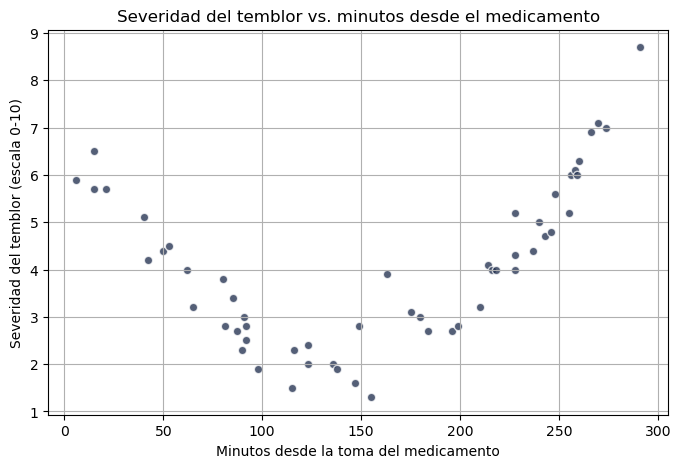

In [5]:
# Visualización de la relación entre las variables
plt.scatter(df['minutos_desde_medicamento'], df['severidad_temblor'], color='#1B2A4A', alpha=0.75, edgecolor='white')
plt.title('Severidad del temblor vs. minutos desde el medicamento')
plt.xlabel('Minutos desde la toma del medicamento')
plt.ylabel('Severidad del temblor (escala 0-10)')
plt.show()

Como se observa en la gráfica de dispersión, los datos **no siguen una línea recta**: la severidad disminuye tras la toma del medicamento, llega a un punto mínimo (mayor alivio) y luego vuelve a subir conforme el efecto se desvanece. Este patrón en forma de "U" confirma que un modelo **polinomial** es más adecuado que uno lineal simple.

## 3. Preprocesamiento

Pasos realizados:

1. Verificación de valores nulos o duplicados.
2. Separación de variables independiente (`X`) y dependiente (`y`).
3. División en conjunto de entrenamiento y prueba (80% / 20%).

In [6]:
# 3.1 Verificación de calidad de datos
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
minutos_desde_medicamento    0
severidad_temblor            0
dtype: int64

Filas duplicadas: 0


In [7]:
# 3.2 Separación de variables
X = df[['minutos_desde_medicamento']].values   # Variable independiente
y = df['severidad_temblor'].values             # Variable dependiente

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (55, 1)
y shape: (55,)


In [8]:
# 3.3 División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Registros de entrenamiento: {len(X_train)}")
print(f"Registros de prueba: {len(X_test)}")

Registros de entrenamiento: 44
Registros de prueba: 11


## 4. Entrenamiento del algoritmo

La Regresión Polinomial se implementa en dos pasos con scikit-learn:

1. **`PolynomialFeatures`**: transforma la variable original `X` en un nuevo conjunto de características que incluye potencias de `X` (X, X², X³, ..., Xⁿ).
2. **`LinearRegression`**: ajusta un modelo lineal sobre esas nuevas características transformadas.

Primero comparamos varios grados de polinomio para elegir el que mejor generaliza, evitando *underfitting* (grado muy bajo) y *overfitting* (grado muy alto).

In [9]:
# 4.1 Comparación de distintos grados de polinomio
grados = range(1, 7)
resultados = []

for grado in grados:
    poly = PolynomialFeatures(degree=grado)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    modelo_temp = LinearRegression()
    modelo_temp.fit(X_train_poly, y_train)

    r2_train = modelo_temp.score(X_train_poly, y_train)
    r2_test = modelo_temp.score(X_test_poly, y_test)

    resultados.append({'grado': grado, 'R2_entrenamiento': r2_train, 'R2_prueba': r2_test})

df_resultados = pd.DataFrame(resultados)
df_resultados

,grado,R2_entrenamiento,R2_prueba
0,1,0.100837,0.229567
1,2,0.924058,0.924748
2,3,0.924490,0.927001
3,4,0.925861,0.920443
4,5,0.935022,0.910291
5,6,0.934683,0.914548


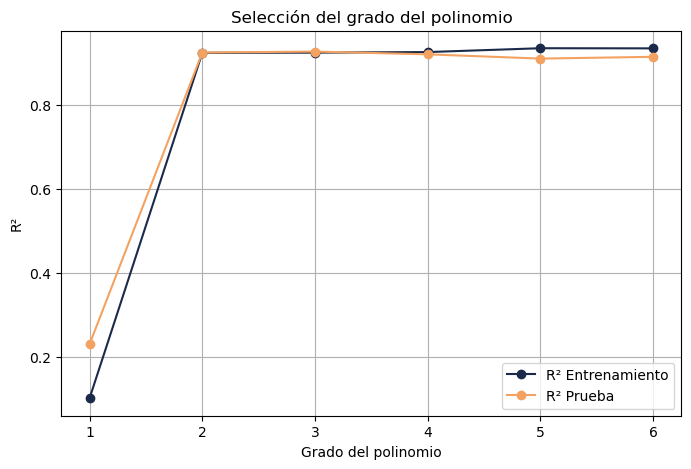

Un R² de entrenamiento que sigue subiendo mientras el de prueba baja es señal de overfitting.


In [10]:
# Visualización: R² por grado del polinomio (train vs test)
plt.plot(df_resultados['grado'], df_resultados['R2_entrenamiento'], marker='o', label='R² Entrenamiento', color='#1B2A4A')
plt.plot(df_resultados['grado'], df_resultados['R2_prueba'], marker='o', label='R² Prueba', color='#F4A261')
plt.title('Selección del grado del polinomio')
plt.xlabel('Grado del polinomio')
plt.ylabel('R²')
plt.legend()
plt.show()

print("Un R² de entrenamiento que sigue subiendo mientras el de prueba baja es señal de overfitting.")

Dado que la relación tiene forma de "U", se espera que un **grado 2** ya capture bien el patrón (una parábola). Se selecciona el grado con mejor R² de prueba sin señales de sobreajuste.

In [11]:
# 4.2 Entrenamiento del modelo final con el grado seleccionado
grado_seleccionado = 2

poly_features = PolynomialFeatures(degree=grado_seleccionado)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_poly, y_train)

print("Modelo entrenado ✅")
print("Coeficientes:", modelo.coef_)
print("Intercepto:", modelo.intercept_)

Modelo entrenado ✅
Coeficientes: [ 0.         -0.071555    0.00026232]
Intercepto: 7.067911505372494


## 5. Evaluación del algoritmo

Se evalúa el modelo con métricas estándar de regresión:

- **R² (coeficiente de determinación):** qué proporción de la variabilidad explica el modelo.
- **MSE (Error Cuadrático Medio):** penaliza más los errores grandes.
- **RMSE (Raíz del Error Cuadrático Medio):** en las mismas unidades que la variable objetivo.
- **MAE (Error Absoluto Medio):** error promedio en valor absoluto.

In [12]:
# 5.1 Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_poly)

# 5.2 Cálculo de métricas
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

R²   : 0.9247
MSE  : 0.1856
RMSE : 0.4308
MAE  : 0.3754


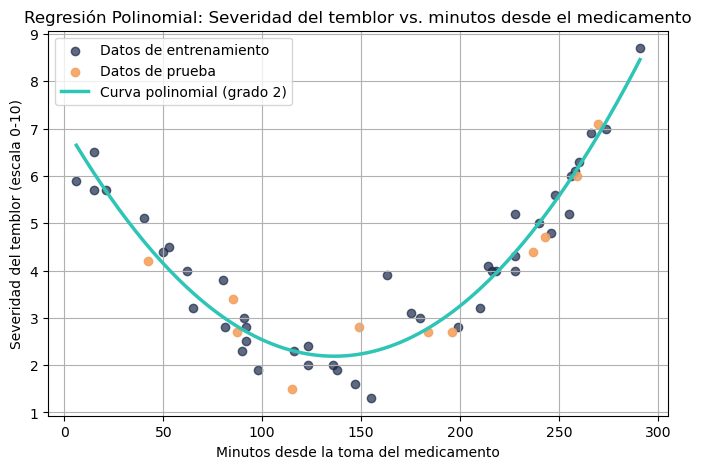

In [13]:
# 5.3 Visualización de la curva ajustada sobre todos los datos
X_rango = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_rango_poly = poly_features.transform(X_rango)
y_rango_pred = modelo.predict(X_rango_poly)

plt.scatter(X_train, y_train, color='#1B2A4A', alpha=0.7, label='Datos de entrenamiento')
plt.scatter(X_test, y_test, color='#F4A261', alpha=0.9, label='Datos de prueba')
plt.plot(X_rango, y_rango_pred, color='#2EC4B6', linewidth=2.5, label=f'Curva polinomial (grado {grado_seleccionado})')
plt.title('Regresión Polinomial: Severidad del temblor vs. minutos desde el medicamento')
plt.xlabel('Minutos desde la toma del medicamento')
plt.ylabel('Severidad del temblor (escala 0-10)')
plt.legend()
plt.show()

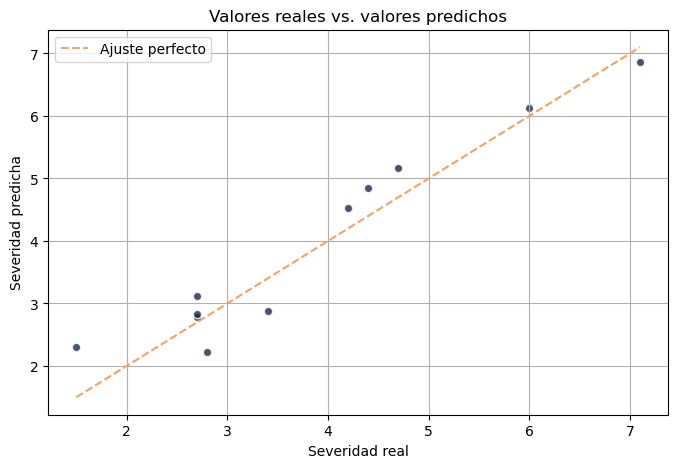

In [14]:
# 5.4 Gráfica de residuos: valores reales vs. predichos
plt.scatter(y_test, y_pred, color='#1B2A4A', alpha=0.8, edgecolor='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#F4A261', linestyle='--', label='Ajuste perfecto')
plt.title('Valores reales vs. valores predichos')
plt.xlabel('Severidad real')
plt.ylabel('Severidad predicha')
plt.legend()
plt.show()

In [15]:
# 5.5 Ejemplo de predicción para un nuevo dato
nuevos_minutos = np.array([[150]])
nuevos_minutos_poly = poly_features.transform(nuevos_minutos)
severidad_estimada = modelo.predict(nuevos_minutos_poly)

print(f"Severidad estimada del temblor a los {nuevos_minutos[0][0]} minutos: {severidad_estimada[0]:.2f} (escala 0-10)")

Severidad estimada del temblor a los 150 minutos: 2.24 (escala 0-10)


## Conclusiones

- La Regresión Polinomial permitió modelar una relación **no lineal** (en forma de "U") entre el tiempo transcurrido desde la toma del medicamento y la severidad del temblor, algo que una regresión lineal simple no habría capturado correctamente.
- El **grado 2** resultó suficiente para representar este patrón, ya que la curva tiene un único punto de inflexión (el momento de mayor alivio).
- Las métricas de evaluación (R², MSE, RMSE, MAE) permiten cuantificar qué tan bien generaliza el modelo a datos que no vio durante el entrenamiento.
- Este análisis es **ilustrativo**: usa datos simulados para fines de esta entrega académica. En una etapa posterior del proyecto NeuroTrack, este mismo enfoque podría aplicarse a registros reales de severidad de síntomas capturados a través de la aplicación, una vez que se cuente con datos suficientes.